In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


In [6]:
def getBiasesBySTR(STR, dfs):
    biases = []
    for df in dfs:
        bias = df.loc[STR, "EFFECT"]
        biases.append(bias)
    biases = np.array(biases)
    return biases

def AddPvalue(DF, ContDF):
    for CT, row in DF.iterrows():
        mat_bias = getBiasesBySTR(CT, ContDF)
        Z, P = GetPermutationP(mat_bias, row["EFFECT"])
        DF.loc[CT, "Pvalue"] = P

    # Import statsmodels.stats.multitest instead of using scipy.stats.multipletests
    from statsmodels.stats.multitest import multipletests
    
    acc, qvalues = multipletests(DF["Pvalue"].values, alpha=0.1,
                                method="fdr_i")[0:2]
    DF["qvalues"] = qvalues
    return DF

def PlotQQ(DFList, NameList):
    plt.figure(dpi=120, figsize=(6, 6))
    sns.set(style="whitegrid", context="talk")
    for DF, name in zip(DFList, NameList):
        DF_Pvals = DF["Pvalue"].values
        Qexp, Qobs = GetExpQ(DF_Pvals)
        plt.scatter(Qexp, Qobs , alpha=0.7, s=50, label=name)
    max_val = 4.5
    plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    plt.xlabel('Expected -log10(p-value)', fontsize=25, weight='bold')
    plt.ylabel('Observed -log10(p-value)', fontsize=25, weight='bold')
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    # Add grid
    plt.grid(True, linestyle='--', alpha=0.5)
    # Tight layout
    plt.tight_layout()
    plt.legend(fontsize=15, loc="lower right")
    #plt.title()
    plt.show()

def LoadNullDF(Ctrl_DIR):
    RandGDFs = []
    for i in range(10000):
        try:
            DF = pd.read_csv("{}/cont.bias.{}.csv.gz".format(Ctrl_DIR, i), index_col=0)
            RandGDFs.append(DF)
        except:
            continue
    print(len(RandGDFs))
    return RandGDFs


# Cluster

### 22q.11 and Other CNVs

In [56]:
RandGDIR_46G = "/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGeneBias/RandGenes_22q/"
RandGDFs_46G = LoadNullDF(RandGDIR_46G)

10000


In [57]:
X22q_Bias = pd.read_csv("../dat/Bias_Feb27_2025/HCT.X22q.Z2.HCT.csv", index_col=0)
X22q_Bias_46_P_randG = AddPvalue(X22q_Bias, RandGDFs_46G)



In [58]:
X22q_Bias_46_P_randG.head(10)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation,Pvalue,qvalues
400,0.570685,1,NEUR,Splatter,NaN,CHOL VGLUT3,"Basal forebrain: 54.0%, Amygdala: 22.9%, Hypot...","Human SI: 18.9%, Human BNST: 13.9%, Human HTHp...",769.0,CHGA CHGB GNRH IGF NAMPT NPPC NUCB PENK SCG UB...,0.0001,0.007683
136,0.488321,2,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Amygdala: 54.6%, Cerebral cortex: 36.2%, Hypot...","Human CoA: 54.6%, Human AON: 28.3%, Human HTHs...",152.0,ADCYAP CBLN CCK CHGA CHGB CRH NAMPT NUCB PYY S...,0.0001,0.007683
149,0.451621,3,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1,"Cerebral cortex: 98.6%, Basal forebrain: 0.6%,...","Human M1C: 24.6%, Human MTG: 8.2%, Human S1C: ...",31428.0,ADCYAP CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL U...,0.0002,0.011524
148,0.442337,4,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1,"Cerebral cortex: 85.2%, Basal forebrain: 6.0%,...","Human MTG: 7.7%, Human ACC: 7.4%, Human FI: 6.6%",16196.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL UCN VGF ...,0.0001,0.007683
151,0.437650,5,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2 VGLUT3,"Cerebral cortex: 44.8%, Amygdala: 33.6%, Basal...","Human Cla: 20.0%, Human CEN: 18.2%, Human Pir:...",18750.0,CBLN CCK CHGA CHGB NAMPT NUCB PYY SCG UBL VGF ...,0.0001,0.007683
139,0.431601,6,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 95.2%, Basal forebrain: 1.9%,...","Human MTG: 12.0%, Human M1C: 7.8%, Human A43: ...",24657.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL UCN VGF ...,0.0003,0.013829
147,0.424178,7,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1,"Cerebral cortex: 65.1%, Amygdala: 19.4%, Basal...","Human Cla: 9.4%, Human FI: 6.8%, Human Idg: 5.9%",13265.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL VGF proSAAS,0.0001,0.007683
150,0.420067,8,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 95.3%, Hippocampus: 2.2%, Bas...","Human M1C: 11.9%, Human MTG: 7.3%, Human A23: ...",12307.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL VGF proSAAS,0.0005,0.019206
137,0.415334,9,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 94.4%, Basal forebrain: 2.1%,...","Human MTG: 7.5%, Human A13: 5.6%, Human M1C: 4.6%",17737.0,CBLN CCK CHGA CHGB CRH NAMPT NUCB SCG UBL UCN ...,0.0008,0.026340
144,0.404776,10,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1,"Cerebral cortex: 96.2%, Basal forebrain: 1.4%,...","Human MTG: 13.0%, Human M1C: 10.4%, Human A43:...",27079.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL UCN VGF ...,0.0002,0.011524


In [12]:
RandGDIR_22q_small_del = "/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGeneBias/RandGenes_22q_small_del/"
RandGDFs_22q_small_del = LoadNullDF(RandGDIR_22q_small_del)

10000


In [16]:
X22q_small_del_Bias = pd.read_csv("../dat/Bias_Feb27_2025/HCT.X22q.mousemodel.Z2.HCT.csv", index_col=0)
X22q_small_del_Bias_P_randG = AddPvalue(X22q_small_del_Bias, RandGDFs_22q_small_del)

In [17]:
X22q_small_del_Bias_P_randG.head(10)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation,Pvalue,qvalues
38,0.656376,1,OLIGO,Committed oligodendrocyte precursor,COP,NaN,"Hippocampus: 29.9%, Cerebral cortex: 29.5%, Po...","Human CA1: 8.9%, Human A35r: 6.5%, Human PnEN:...",779.0,NXPH proSAAS,0.000200,0.046095
400,0.656295,2,NEUR,Splatter,NaN,CHOL VGLUT3,"Basal forebrain: 54.0%, Amygdala: 22.9%, Hypot...","Human SI: 18.9%, Human BNST: 13.9%, Human HTHp...",769.0,CHGA CHGB GNRH IGF NAMPT NPPC NUCB PENK SCG UB...,0.000100,0.046095
347,0.580493,3,NEUR,Splatter,NaN,GLY,"Medulla: 68.6%, Spinal cord: 29.3%, Pons: 0.9%","Human MoAN: 33.4%, Human SpC: 29.3%, Human MoS...",2434.0,CCK CHGA CHGB NAMPT NPPC NUCB NXPH PDYN PNOC S...,0.001300,0.085606
451,0.526602,4,NEUR,Thalamic excitatory,NaN,VGLUT2,"Thalamus: 99.9%, Midbrain: 0.1%, Hypothalamus:...","Human MD: 29.1%, Human ETH: 20.1%, Human ANC: ...",9740.0,ADCYAP ADM CART CBLN CCK CHGA CHGB CRH GAL NAM...,0.000700,0.085606
455,0.489546,5,NEUR,Thalamic excitatory,NaN,VGLUT2,"Thalamus: 97.9%, Midbrain: 2.1%, Cerebral cort...","Human Pul: 40.5%, Human ETH: 38.2%, Human MD: ...",474.0,ADCYAP ADM CART CBLN CCK CHGA CHGB CRH GAL NAM...,0.001000,0.085606
450,0.485647,6,NEUR,Thalamic excitatory,NaN,VGLUT2,"Thalamus: 99.9%, Basal forebrain: 0.0%, Hypoth...","Human MD: 45.8%, Human ANC: 20.8%, Human ETH: ...",3092.0,ADCYAP ADM CART CBLN CCK CHGA CHGB CRH NAMPT N...,0.001300,0.085606
458,0.480108,7,NEUR,Thalamic excitatory,NaN,VGLUT2,"Thalamus: 93.6%, Midbrain: 6.4%, Amygdala: 0.0%","Human ETH: 22.6%, Human MD: 19.4%, Human ANC: ...",7494.0,ADCYAP ADM CART CBLN CCK CHGA CHGB CRH GAL NAM...,0.000900,0.085606
454,0.473670,8,NEUR,Thalamic excitatory,NaN,VGLUT2,"Thalamus: 99.5%, Midbrain: 0.5%, Cerebral cort...","Human Pul: 76.9%, Human LP: 8.6%, Human ETH: 7.5%",11893.0,ADCYAP ADM CART CBLN CCK CHGA CHGB CRH GAL NAM...,0.003600,0.181501
313,0.447428,9,NEUR,Splatter,NaN,VGLUT2,"Hippocampus: 41.6%, Cerebral cortex: 36.5%, Am...","Human MEC: 14.5%, Human CA4C-DGC: 10.7%, Human...",449.0,ADCYAP CHGB NAMPT NPPC NUCB SCG UBL proSAAS,0.005199,0.181501
272,0.423793,10,NEUR,LAMP5-LHX6 and Chandelier,INT-LAMP5-LHX6,GABA,"Cerebral cortex: 67.5%, Amygdala: 16.1%, Basal...","Human MEC: 6.2%, Human FI: 5.9%, Human LEC: 4.8%",1960.0,CCK CHGA CHGB CORT IGF NAMPT NPPC NUCB NXPH PN...,0.004500,0.181501


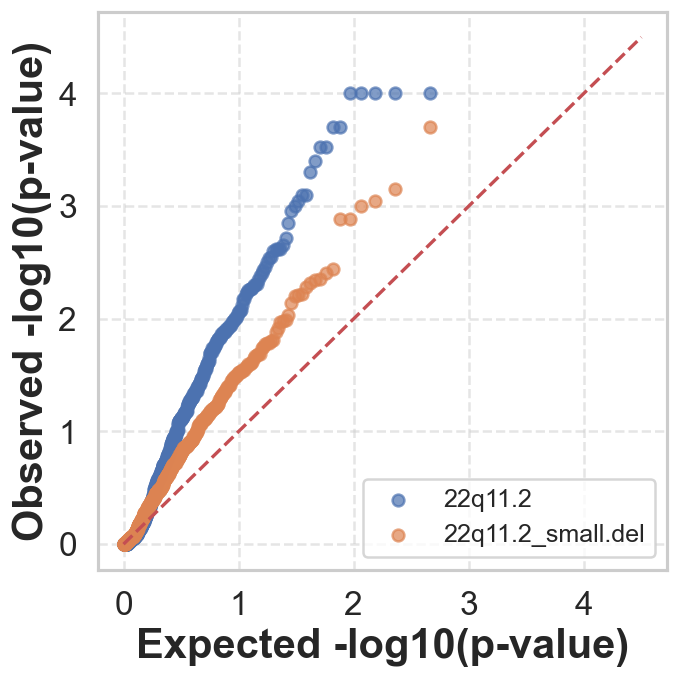

In [59]:
PlotQQ([X22q_Bias_46_P_randG, X22q_small_del_Bias_P_randG], [ "22q11.2", "22q11.2_small.del"])

In [60]:
supercluster_to_test = "CGE interneuron"
supercluster_idx = Anno[Anno["Supercluster"]==supercluster_to_test].index
def test_supercluster_enrichment(supercluster_idx, ObsDF, RandDFs, print_flag = False):
    Obs = ObsDF.loc[supercluster_idx, "EFFECT"].mean()


    Null = []
    for df in RandDFs:
        eff = df.loc[supercluster_idx, "EFFECT"].mean()
        Null.append(eff)
    Null = np.array(Null)

    Z, P = GetPermutationP(Null, Obs)
    if print_flag:
        print(f"Observed effect for {supercluster_to_test}: {Obs}")
        print(f"P-value: {P}")
    return Obs, Null, Z, P

In [61]:
supercluster_to_test = "CGE interneuron"
supercluster_idx = Anno[Anno["Supercluster"]==supercluster_to_test].index
test_supercluster_enrichment(supercluster_idx, X22q_Bias_46_P_randG, RandGDFs_46G)

(0.1771488764927199,
 array([ 0.14132797, -0.09724315, -0.12994697, ...,  0.16944778,
        -0.05226399,  0.00096522]),
 2.0886020138233254,
 0.020197980201979826)

In [62]:
supercluster_to_test = "LAMP5-LHX6 and Chandelier"
supercluster_idx = Anno[Anno["Supercluster"]==supercluster_to_test].index
test_supercluster_enrichment(supercluster_idx, X22q_Bias_46_P_randG, RandGDFs_46G)

(0.10567521960636718,
 array([ 0.13037025, -0.0815577 , -0.09116953, ..., -0.05158161,
        -0.13635358, -0.01050781]),
 1.412095381452662,
 0.08329167083291666)

In [63]:
supercluster_to_test = "MGE interneuron"
supercluster_idx = Anno[Anno["Supercluster"]==supercluster_to_test].index
test_supercluster_enrichment(supercluster_idx, X22q_Bias_46_P_randG, RandGDFs_46G)

(-0.04658828691020462,
 array([ 0.11524388, -0.06121767, -0.08880028, ...,  0.08083011,
        -0.07531407,  0.01992512]),
 -0.2319624475077848,
 0.5864413558644135)

In [64]:
def test_all_superclusters(ALL_CTs, Anno, ObsBiasDF , RandGDFs):
    results = []
    for supercluster_to_test in ALL_CTs:
        supercluster_idx = Anno[Anno["Supercluster"]==supercluster_to_test].index
        Obs, Null, Z, P = test_supercluster_enrichment(supercluster_idx, ObsBiasDF, RandGDFs)
        results.append({
            'Supercluster': supercluster_to_test,
            'Observed_Effect': Obs,
            'Z_score': Z,
            'P_value': P
        })
    res_DF = pd.DataFrame(results)
    res_DF['FDR'] = multipletests(res_DF['P_value'], method='fdr_bh')[1]
    res_DF = res_DF.sort_values(by='FDR', ascending=True)
    return res_DF

In [65]:
SuperCluster_22q11_df = test_all_superclusters(ALL_CTs, Anno, X22q_Bias_46_P_randG, RandGDFs_46G)

In [66]:
# Apply FDR correction to P-values
SuperCluster_22q11_df['FDR'] = multipletests(SuperCluster_22q11_df['P_value'], method='fdr_bh')[1]
SuperCluster_22q11_df = SuperCluster_22q11_df.sort_values(by='FDR', ascending=True)

In [67]:
SuperCluster_22q11_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
4,Deep-layer intratelencephalic,0.360598,4.221677,0.000100,0.003100
3,Deep-layer corticothalamic and 6b,0.263611,3.011486,0.001100,0.017048
20,Upper-layer intratelencephalic,0.249631,2.702865,0.003000,0.030997
18,Thalamic excitatory,0.172464,2.220034,0.014099,0.109264
1,CGE interneuron,0.177149,2.088602,0.020198,0.125227
8,Hippocampal CA4,0.152104,1.975658,0.024298,0.125537
5,Deep-layer near-projecting,0.139264,1.651808,0.051295,0.227163
0,Amygdala excitatory,0.079469,1.292615,0.096090,0.248234
7,Hippocampal CA1-3,0.077502,1.395133,0.081692,0.248234
17,Splatter,0.064739,1.351589,0.088791,0.248234


In [68]:
def test_supercluster_enrichment(supercluster_idx, ObsDF, RandDFs):
    Obs = ObsDF.loc[supercluster_idx, "EFFECT"].mean()
    print(f"Observed effect for {supercluster_to_test}: {Obs}")

    Null = []
    for df in RandDFs:
        eff = df.loc[supercluster_idx, "EFFECT"].mean()
        Null.append(eff)
    Null = np.array(Null)

    Z, P = GetPermutationP(Null, Obs)
    print(f"P-value: {P}")
    return Obs, Null, Z, P

VIP_Pos_idx = [276, 279, 280, 281, 284, 285, 289, 290, 291, 292, 293, 294, 295, 296]
test_supercluster_enrichment(VIP_Pos_idx, X22q_Bias_46_P_randG, RandGDFs_46G)

Observed effect for MGE interneuron: 0.21199822414196162
P-value: 0.01159884011598844


(0.21199822414196162,
 array([ 0.11370317, -0.07043611, -0.14680811, ...,  0.20818695,
        -0.06709576, -0.01070213]),
 2.350198282486196,
 0.01159884011598844)

In [70]:
SuperCluster_22q11_df_addVIP = pd.concat([SuperCluster_22q11_df, pd.DataFrame([{
    'Supercluster': 'VIP+ CGE',
    'Observed_Effect': 0.212,
    'Z_score': 2.47,
    'P_value': 0.01159884011598844,
    'FDR': None
}])])

In [71]:
SuperCluster_22q11_df_addVIP['FDR'] = multipletests(SuperCluster_22q11_df_addVIP['P_value'], method='fdr_bh')[1]
SuperCluster_22q11_df_addVIP = SuperCluster_22q11_df_addVIP.sort_values(by='FDR', ascending=True)

In [72]:
SuperCluster_22q11_df_addVIP

,Supercluster,Observed_Effect,Z_score,P_value,FDR
4,Deep-layer intratelencephalic,0.360598,4.221677,0.000100,0.003200
3,Deep-layer corticothalamic and 6b,0.263611,3.011486,0.001100,0.017598
20,Upper-layer intratelencephalic,0.249631,2.702865,0.003000,0.031997
0,VIP+ CGE,0.212000,2.470000,0.011599,0.090231
18,Thalamic excitatory,0.172464,2.220034,0.014099,0.090231
1,CGE interneuron,0.177149,2.088602,0.020198,0.107723
8,Hippocampal CA4,0.152104,1.975658,0.024298,0.111075
5,Deep-layer near-projecting,0.139264,1.651808,0.051295,0.205179
0,Amygdala excitatory,0.079469,1.292615,0.096090,0.236530
7,Hippocampal CA1-3,0.077502,1.395133,0.081692,0.236530


In [73]:
SuperCluster_22q11_df_addVIP_Neurons = SuperCluster_22q11_df_addVIP[~SuperCluster_22q11_df_addVIP["Supercluster"].isin(Not_Neurons)]

In [74]:
SuperCluster_22q11_df_addVIP_Neurons['FDR'] = multipletests(SuperCluster_22q11_df_addVIP_Neurons['P_value'], method='fdr_bh')[1]
SuperCluster_22q11_df_addVIP_Neurons = SuperCluster_22q11_df_addVIP_Neurons.sort_values(by='FDR', ascending=True)

/tmp/ipykernel_1145552/3709567054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SuperCluster_22q11_df_addVIP_Neurons['FDR'] = multipletests(SuperCluster_22q11_df_addVIP_Neurons['P_value'], method='fdr_bh')[1]


In [75]:
SuperCluster_22q11_df_addVIP_Neurons

,Supercluster,Observed_Effect,Z_score,P_value,FDR
4,Deep-layer intratelencephalic,0.360598,4.221677,0.000100,0.002200
3,Deep-layer corticothalamic and 6b,0.263611,3.011486,0.001100,0.012099
20,Upper-layer intratelencephalic,0.249631,2.702865,0.003000,0.021998
0,VIP+ CGE,0.212000,2.470000,0.011599,0.062034
18,Thalamic excitatory,0.172464,2.220034,0.014099,0.062034
1,CGE interneuron,0.177149,2.088602,0.020198,0.074059
8,Hippocampal CA4,0.152104,1.975658,0.024298,0.076364
5,Deep-layer near-projecting,0.139264,1.651808,0.051295,0.141061
16,Miscellaneous,0.055757,1.411419,0.077992,0.162615
10,LAMP5-LHX6 and Chandelier,0.105675,1.412095,0.083292,0.162615


In [77]:
#AddPvalue(genes_22q_small_del_Bias, RandGDFs_22q_small_del)
SuperCluster_22q11_SD_df = test_all_superclusters(ALL_CTs, Anno, X22q_small_del_Bias_P_randG, RandGDFs_22q_small_del)

Observed effect for MGE interneuron: 0.0238313658689523
P-value: 0.2932706729327067
Observed effect for MGE interneuron: 0.2070666766192314
P-value: 0.038296170382961736
Observed effect for MGE interneuron: -0.02110868350668698
P-value: 0.4644535546445355
Observed effect for MGE interneuron: 0.23147939266734258
P-value: 0.01439856014398555
Observed effect for MGE interneuron: 0.2181984055370949
P-value: 0.00989901009899008
Observed effect for MGE interneuron: 0.12026817882196404
P-value: 0.12408759124087587
Observed effect for MGE interneuron: -0.1932472965194525
P-value: 0.9028097190280971
Observed effect for MGE interneuron: 0.05690343752109864
P-value: 0.18338166183381666
Observed effect for MGE interneuron: 0.0868064032331623
P-value: 0.1382861713828617
Observed effect for MGE interneuron: 0.14476250397094795
P-value: 0.21987801219878012
Observed effect for MGE interneuron: 0.10237445341660363
P-value: 0.1455854414558544
Observed effect for MGE interneuron: 0.0348415501365044
P-val

In [79]:
SuperCluster_22q11_SD_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
3,Deep-layer corticothalamic and 6b,0.231479,2.113098,0.014399,0.148785
4,Deep-layer intratelencephalic,0.218198,2.238764,0.009899,0.148785
18,Thalamic excitatory,0.290623,2.479592,0.006999,0.148785
1,CGE interneuron,0.207067,1.836314,0.038296,0.296795
20,Upper-layer intratelencephalic,0.150766,1.400047,0.080492,0.499050
5,Deep-layer near-projecting,0.120268,1.179360,0.124088,0.501461
8,Hippocampal CA4,0.086806,1.080701,0.138286,0.501461
10,LAMP5-LHX6 and Chandelier,0.102374,1.056781,0.145585,0.501461
17,Splatter,0.077562,1.158116,0.121388,0.501461
7,Hippocampal CA1-3,0.056903,0.888802,0.183382,0.568483


#### VIP subtype comparison 

In [45]:
CGE_VIP_Pos_list = np.loadtxt("../dat/Other/CGE_VIP_Pos.txt", dtype=int)
CGE_VIP_Neg_list = np.loadtxt("../dat/Other/CGE_VIP_Neg.txt", dtype=int)

In [48]:
VIP_pos_meanBias = X22q_Bias_46_P_randG[X22q_Bias_46_P_randG.index.isin(CGE_VIP_Pos_list)]["EFFECT"].mean()
VIP_neg_meanBias = X22q_Bias_46_P_randG[X22q_Bias_46_P_randG.index.isin(CGE_VIP_Neg_list)]["EFFECT"].mean()
DIFF_obs = VIP_pos_meanBias - VIP_neg_meanBias
print(VIP_pos_meanBias, VIP_neg_meanBias, VIP_pos_meanBias - VIP_neg_meanBias)



0.21199822414196162 0.10745018119423648 0.10454804294772514


In [80]:
null_diffs = []
#for i in range(10000):
for i in range(len(RandGDFs_46G)):
    tmpDF = RandGDFs_46G[i]
    tmp_VIP_pos_meanBias = tmpDF[tmpDF.index.isin(CGE_VIP_Pos_list)]["EFFECT"].mean()
    tmp_VIP_neg_meanBias = tmpDF[tmpDF.index.isin(CGE_VIP_Neg_list)]["EFFECT"].mean()
    null_diffs.append(tmp_VIP_pos_meanBias - tmp_VIP_neg_meanBias)
null_diffs = np.array(null_diffs)


Observed difference: 0.105
P-value: 6.660e-02


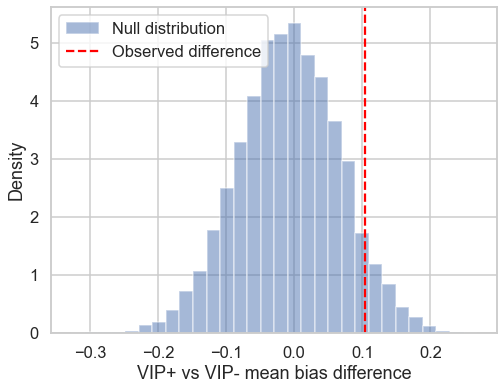

In [81]:
# Plot observed difference vs null distribution
plt.figure(figsize=(8,6))
plt.hist(null_diffs, bins=30, density=True, alpha=0.5, label='Null distribution')
plt.axvline(DIFF_obs, color='red', linestyle='dashed', label='Observed difference')
plt.xlabel('VIP+ vs VIP- mean bias difference')
plt.ylabel('Density')
plt.legend()

#compute 1-sided p-value
pval = np.mean(null_diffs >= DIFF_obs)
print(f"Observed difference: {DIFF_obs:.3f}")
print(f"P-value: {pval:.3e}")

### ASD/SCZ/VNR top 61 genes

In [96]:
RandG_ASD_HIQ_top61_DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGeneBias/RandGenes_ASD_HIQ.top61/"
RandG_ASD_HIQ_top61_DFs = LoadNullDF(RandG_ASD_HIQ_top61_DIR)

10000


In [97]:
ASD_HIQ_Bias_top61 = pd.read_csv("../dat/Bias_Feb27_2025/HCT.ASD61.HIQ.Z2.HCT.csv", index_col=0)
ASD_HIQ_Bias_top61_P_randG = AddPvalue(ASD_HIQ_Bias_top61, RandG_ASD_HIQ_top61_DFs)

In [98]:
SuperCluster_ASD_HIQ_df = test_all_superclusters(ALL_CTs, Anno, ASD_HIQ_Bias_top61_P_randG, RandG_ASD_HIQ_top61_DFs)    

Observed effect for CGE interneuron: 0.2712119110398278
P-value: 0.006999300069993053
Observed effect for CGE interneuron: -0.1318945495892537
P-value: 0.8098190180981901
Observed effect for CGE interneuron: -0.18099907764185258
P-value: 0.8879112088791121
Observed effect for CGE interneuron: 0.13614861194893133
P-value: 0.06219378062193781
Observed effect for CGE interneuron: 0.25511112929561247
P-value: 0.005699430056994248
Observed effect for CGE interneuron: 0.02492185134404085
P-value: 0.2691730826917308
Observed effect for CGE interneuron: 0.06737581471113394
P-value: 0.2918708129187081
Observed effect for CGE interneuron: 0.14386426227697052
P-value: 0.06319368063193675
Observed effect for CGE interneuron: 0.1232957662949795
P-value: 0.09509049095090494
Observed effect for CGE interneuron: -0.0036384307429212425
P-value: 0.5724427557244276
Observed effect for CGE interneuron: -0.1312876516385058
P-value: 0.7181281871812819
Observed effect for CGE interneuron: -0.1047177235757180

In [102]:
SuperCluster_ASD_HIQ_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
0,Amygdala excitatory,0.271212,2.391691,0.006999,0.108489
4,Deep-layer intratelencephalic,0.255111,2.533638,0.005699,0.108489
3,Deep-layer corticothalamic and 6b,0.136149,1.509589,0.062194,0.391801
14,Medium spiny neuron,0.184728,1.536206,0.061994,0.391801
7,Hippocampal CA1-3,0.143864,1.525376,0.063194,0.391801
8,Hippocampal CA4,0.123296,1.304623,0.095090,0.491301
20,Upper-layer intratelencephalic,0.094199,1.041695,0.147885,0.654920
13,Mammillary body,0.078404,0.947307,0.172483,0.668371
23,Choroid plexus,0.157167,0.715685,0.228277,0.707659
15,Midbrain-derived inhibitory,0.101762,0.728929,0.222478,0.707659


In [99]:
RandG_ASD_LIQ_top61_DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGeneBias/RandGenes_ASD_LIQ.top61/"
RandG_ASD_LIQ_top61_DFs = LoadNullDF(RandG_ASD_LIQ_top61_DIR)

10000


In [100]:
ASD_LIQ_Bias_top61 = pd.read_csv("../dat/Bias_Feb27_2025/HCT.ASD61.LIQ.Z2.HCT.csv", index_col=0)
ASD_LIQ_Bias_top61_P_randG = AddPvalue(ASD_LIQ_Bias_top61, RandG_ASD_LIQ_top61_DFs)

In [101]:
SuperCluster_ASD_LIQ_df = test_all_superclusters(ALL_CTs, Anno, ASD_LIQ_Bias_top61_P_randG, RandG_ASD_LIQ_top61_DFs)   

Observed effect for CGE interneuron: 0.23061429647445236
P-value: 0.011498850114988524
Observed effect for CGE interneuron: 0.11173698927254366
P-value: 0.13238676132386762
Observed effect for CGE interneuron: -0.1098060749570892
P-value: 0.7407259274072593
Observed effect for CGE interneuron: 0.14620225770267015
P-value: 0.05429457054294573
Observed effect for CGE interneuron: 0.20084591614995972
P-value: 0.012398760123987551
Observed effect for CGE interneuron: 0.01922665246813293
P-value: 0.2698730126987301
Observed effect for CGE interneuron: 0.11300260429131992
P-value: 0.18188181181881813
Observed effect for CGE interneuron: 0.2085571014580677
P-value: 0.01839816018398155
Observed effect for CGE interneuron: 0.14716798360936106
P-value: 0.060393960603939645
Observed effect for CGE interneuron: 0.08933644147636678
P-value: 0.3274672532746725
Observed effect for CGE interneuron: 0.14652788955861942
P-value: 0.0781921807819218
Observed effect for CGE interneuron: -0.3892967108915374

In [103]:
SuperCluster_ASD_LIQ_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
0,Amygdala excitatory,0.230614,2.190394,0.011499,0.190114
4,Deep-layer intratelencephalic,0.200846,2.202779,0.012399,0.190114
7,Hippocampal CA1-3,0.208557,2.096335,0.018398,0.190114
14,Medium spiny neuron,0.241318,2.005455,0.026997,0.209229
10,LAMP5-LHX6 and Chandelier,0.146528,1.435484,0.078192,0.302995
8,Hippocampal CA4,0.147168,1.548095,0.060394,0.302995
15,Midbrain-derived inhibitory,0.210301,1.471969,0.075992,0.302995
3,Deep-layer corticothalamic and 6b,0.146202,1.613257,0.054295,0.302995
1,CGE interneuron,0.111737,1.109177,0.132387,0.444496
20,Upper-layer intratelencephalic,0.093013,1.063657,0.143386,0.444496


In [82]:
RandG_DDD_top61_DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGeneBias/RandGenes_DDD.top61/"
RandG_DDD_top61_DFs = LoadNullDF(RandG_DDD_top61_DIR)

10000


In [83]:
#DDD_hc_Bias_top61 = pd.read_csv("../dat/Bias/HCT.DDDHC.Z2.HCT.top61.csv", index_col=0)
DDD_hc_Bias_top61 = pd.read_csv("../dat/Bias_Feb27_2025/HCT.DDDHC.Z2.HCT.top61.csv", index_col=0)
DDD_hc_Bias_top61_P_randG = AddPvalue(DDD_hc_Bias_top61, RandG_DDD_top61_DFs)

In [84]:
DDD_hc_Bias_top61_P_randG.head(30)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation,Pvalue,qvalues
136,0.609261,1,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Amygdala: 54.6%, Cerebral cortex: 36.2%, Hypot...","Human CoA: 54.6%, Human AON: 28.3%, Human HTHs...",152.0,ADCYAP CBLN CCK CHGA CHGB CRH NAMPT NUCB PYY S...,0.000100,0.023048
135,0.563419,2,NEUR,Upper-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 95.4%, Basal forebrain: 2.7%,...","Human M1C: 10.7%, Human A1C: 7.5%, Human MTG: ...",28248.0,ADCYAP CBLN CCK CHGA CHGB GAL NAMPT NUCB NXPH ...,0.000100,0.023048
138,0.484404,3,NEUR,Upper-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 96.4%, Basal forebrain: 1.2%,...","Human MTG: 14.3%, Human V2: 5.2%, Human A19: 4.5%",58263.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL VGF proSAAS,0.000300,0.034572
179,0.454178,4,NEUR,Hippocampal CA1-3,NaN,VGLUT1,"Hippocampus: 97.2%, Cerebral cortex: 2.8%, Amy...","Human CA1C-CA3C: 40.8%, Human CA4C-DGC: 19.4%,...",8293.0,CBLN CHGA CHGB NAMPT NUCB UBL proSAAS,0.009099,0.079145
132,0.440331,5,NEUR,Miscellaneous,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 98.4%, Hippocampus: 0.8%, Mid...","Human A29-A30: 90.9%, Human Pro: 5.1%, Human M...",492.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL VGF proSAAS,0.001400,0.053778
278,0.438523,6,NEUR,CGE interneuron,NaN,GABA VGLUT3,"Cerebral cortex: 78.0%, Amygdala: 10.4%, Hippo...","Human MEC: 5.9%, Human LEC: 4.8%, Human M1C: 4.7%",7177.0,CCK CHGA CHGB CRH IGF NAMPT NPW NUCB NXPH PNOC...,0.000700,0.051857
141,0.434589,7,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 95.4%, Basal forebrain: 2.0%,...","Human MTG: 7.9%, Human Ig: 6.0%, Human TF: 5.7%",9992.0,CCK CHGA CHGB NAMPT NUCB PDYN SCG UBL VGF proSAAS,0.001300,0.053778
181,0.432825,8,NEUR,Hippocampal CA1-3,NaN,VGLUT1,"Hippocampus: 100.0%, Cerebral cortex: 0.0%, Am...","Human CA1C-CA3C: 28.2%, Human CA1R-CA2R-CA3R: ...",6501.0,CART CBLN CHGA CHGB CORT NAMPT NUCB NXPH SCG U...,0.000300,0.034572
296,0.426360,9,NEUR,CGE interneuron,INT-VIP,GABA,"Cerebral cortex: 72.9%, Amygdala: 10.5%, Hippo...","Human M1C: 8.1%, Human MEC: 6.2%, Human MTG: 4.7%",9524.0,CBLN CCK CHGA CHGB CRH IGF NAMPT NPPC NUCB NXP...,0.005000,0.067672
403,0.411822,10,NEUR,Splatter,NaN,GABA,"Cerebral cortex: 45.6%, Amygdala: 33.5%, Hypot...","Human AON: 25.7%, Human CoA: 18.1%, Human Pir:...",2608.0,CCK CHGB CORT NAMPT NUCB NXPH PENK SCG TAC VGF...,0.011199,0.089012


In [85]:
SuperCluster_DDD_df = test_all_superclusters(ALL_CTs, Anno, DDD_hc_Bias_top61_P_randG, RandGDIR_DDD_top61)

Observed effect for MGE interneuron: 0.07549622834416267
P-value: 0.10368963103689632
Observed effect for MGE interneuron: 0.27736732222906657
P-value: 0.0014998500149985272
Observed effect for MGE interneuron: -0.24743614488673044
P-value: 0.9885011498850115
Observed effect for MGE interneuron: 0.16310524987846928
P-value: 0.012698730126987301
Observed effect for MGE interneuron: 0.3080873653870727
P-value: 0.00019998000199983323
Observed effect for MGE interneuron: 0.20125768755129686
P-value: 0.019098090190980854
Observed effect for MGE interneuron: 0.09370646721103439
P-value: 0.17408259174082596
Observed effect for MGE interneuron: 0.27393676250165766
P-value: 0.0009999000099990552
Observed effect for MGE interneuron: -0.005951140556544697
P-value: 0.2585741425857414
Observed effect for MGE interneuron: -0.03434595569439467
P-value: 0.7045295470452955
Observed effect for MGE interneuron: 0.21960006647035457
P-value: 0.008399160083991553
Observed effect for MGE interneuron: -0.6165

In [86]:
SuperCluster_DDD_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
4,Deep-layer intratelencephalic,0.308087,3.738239,0.000200,0.006199
1,CGE interneuron,0.277367,3.144769,0.001500,0.011624
20,Upper-layer intratelencephalic,0.289014,3.045902,0.001200,0.011624
7,Hippocampal CA1-3,0.273937,3.268493,0.001000,0.011624
16,Miscellaneous,0.145759,2.866561,0.002500,0.015498
10,LAMP5-LHX6 and Chandelier,0.219600,2.475583,0.008399,0.043396
3,Deep-layer corticothalamic and 6b,0.163105,2.148541,0.012699,0.056237
5,Deep-layer near-projecting,0.201258,2.130658,0.019098,0.074005
14,Medium spiny neuron,0.135509,1.589332,0.057894,0.199413
0,Amygdala excitatory,0.075496,1.253476,0.103690,0.321438


In [88]:
# UKBB VNR Neg top 61
RandGDIR_VNR_Neg_top61_DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGeneBias/RandGenes_UKBB_VNR.top61/"
RandG_VNR_Neg_top61_DFs = LoadNullDF(RandGDIR_VNR_Neg_top61_DIR)

10000


In [89]:
VNR_Neg_Bias = pd.read_csv("../dat/Bias_Feb27_2025/CTBias.VNR.Neg.top61.csv", index_col=0)
VNR_Neg_Bias_P_randG = AddPvalue(VNR_Neg_Bias, RandG_VNR_Neg_top61_DFs)

In [90]:
VNR_Neg_Bias_P_randG.head(20)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation,Pvalue,qvalues
219,0.579260,1,NEUR,Medium spiny neuron,MSN-D1,GABA,"Amygdala: 33.2%, Basal forebrain: 32.8%, Hypot...","Human SI: 31.0%, Human BNST: 23.2%, Human HTHp...",8342.0,CHGA CHGB NAMPT NUCB NXPH PDYN PENK SCG TAC UB...,0.000100,0.046095
283,0.422103,2,NEUR,CGE interneuron,NaN,GABA,"Cerebral cortex: 81.0%, Hippocampus: 9.3%, Amy...","Human MTG: 5.2%, Human A32: 4.5%, Human MEC: 4.1%",10636.0,CCK CHGA CHGB IGF NAMPT NUCB NXPH PNOC SCG SST...,0.001100,0.175162
403,0.406767,3,NEUR,Splatter,NaN,GABA,"Cerebral cortex: 45.6%, Amygdala: 33.5%, Hypot...","Human AON: 25.7%, Human CoA: 18.1%, Human Pir:...",2608.0,CCK CHGB CORT NAMPT NUCB NXPH PENK SCG TAC VGF...,0.005499,0.184382
428,0.399089,4,NEUR,Splatter,NaN,GABA,"Basal forebrain: 59.7%, Amygdala: 16.1%, Hypot...","Human SEP: 55.1%, Human BNST: 12.4%, Human ANC...",3182.0,CBLN CCK CHGA CHGB NAMPT NUCB NXPH PNOC SCG UB...,0.001600,0.175162
229,0.392532,5,NEUR,Eccentric medium spiny neuron,MSN-D1,GABA,"Amygdala: 56.1%, Basal forebrain: 28.8%, Cereb...","Human CEN: 21.7%, Human CMN: 17.8%, Human Cla:...",1857.0,CCK CHGA CHGB NAMPT NUCB NXPH PDYN PENK SCG TA...,0.003100,0.175162
296,0.385786,6,NEUR,CGE interneuron,INT-VIP,GABA,"Cerebral cortex: 72.9%, Amygdala: 10.5%, Hippo...","Human M1C: 8.1%, Human MEC: 6.2%, Human MTG: 4.7%",9524.0,CBLN CCK CHGA CHGB CRH IGF NAMPT NPPC NUCB NXP...,0.002600,0.175162
285,0.337378,7,NEUR,CGE interneuron,INT-VIP,GABA,"Cerebral cortex: 62.9%, Hippocampus: 22.3%, Am...","Human M1C: 7.7%, Human CA1C-CA3C: 5.2%, Human ...",4688.0,CCK CHGA CHGB IGF NAMPT NUCB NXPH PENK PNOC SC...,0.001300,0.175162
232,0.320869,8,NEUR,Eccentric medium spiny neuron,MSN-D1,GABA,"Basal forebrain: 32.8%, Amygdala: 30.3%, Hypot...","Human SI: 25.7%, Human HTHpo: 17.0%, Human BNS...",3682.0,CHGB NAMPT NUCB PDYN PENK SCG UBL VGF proSAAS,0.004200,0.176001
225,0.320033,9,NEUR,Eccentric medium spiny neuron,MSN-D1 MSN-ECC,GABA,"Amygdala: 47.2%, Basal forebrain: 33.3%, Cereb...","Human SI: 15.2%, Human BNST: 14.1%, Human La: ...",2296.0,CHGB NAMPT NUCB PDYN PENK SCG TAC UBL VGF proSAAS,0.005999,0.184382
218,0.309485,10,NEUR,Medium spiny neuron,NaN,NaN,"Basal forebrain: 50.9%, Amygdala: 22.3%, Hypot...","Human SI: 38.1%, Human BNST: 19.5%, Human HTHp...",6712.0,CART CCK CHGA CHGB NAMPT NUCB SCG TAC UBL proSAAS,0.009999,0.251220


In [92]:
supercluster_to_test = "CGE interneuron"
supercluster_idx = Anno[Anno["Supercluster"]==supercluster_to_test].index
test_supercluster_enrichment(supercluster_idx, VNR_Neg_Bias_P_randG, RandG_VNR_Neg_top61_DFs)

Observed effect for CGE interneuron: 0.20918755778322012
P-value: 0.006999300069993053


(0.20918755778322012,
 array([ 0.08169182, -0.12154605, -0.03824147, ..., -0.05624483,
        -0.18529319,  0.02980792]),
 2.5912658588529327,
 0.006999300069993053)

In [93]:
SuperCluster_VNR_Neg_df = test_all_superclusters(ALL_CTs, Anno, VNR_Neg_Bias_P_randG, RandG_VNR_Neg_top61_DFs)

Observed effect for CGE interneuron: 0.04243874196711931
P-value: 0.15618438156184378
Observed effect for CGE interneuron: 0.20918755778322012
P-value: 0.006999300069993053
Observed effect for CGE interneuron: 0.0018773798000616625
P-value: 0.3786621337866214
Observed effect for CGE interneuron: -0.15543521511524602
P-value: 0.7442255774422557
Observed effect for CGE interneuron: -0.049806177300320234
P-value: 0.31416858314168583
Observed effect for CGE interneuron: -0.15894607478613032
P-value: 0.7556244375562444
Observed effect for CGE interneuron: 0.2668021638235013
P-value: 0.004499550044995471
Observed effect for CGE interneuron: 0.060930748390390456
P-value: 0.08939106089391058
Observed effect for CGE interneuron: 0.0681825560883066
P-value: 0.08999100089990997
Observed effect for CGE interneuron: 0.037838274487509184
P-value: 0.46605339466053397
Observed effect for CGE interneuron: -0.03842261285450421
P-value: 0.45535446455354467
Observed effect for CGE interneuron: 0.093084681

In [94]:
SuperCluster_VNR_Neg_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
1,CGE interneuron,0.209188,2.591266,0.006999,0.072326
6,Eccentric medium spiny neuron,0.266802,2.684174,0.004500,0.072326
14,Medium spiny neuron,0.243033,2.710442,0.005000,0.072326
18,Thalamic excitatory,0.061749,1.285840,0.099990,0.499493
7,Hippocampal CA1-3,0.060931,1.336487,0.089391,0.499493
8,Hippocampal CA4,0.068183,1.334222,0.089991,0.499493
11,Lower rhombic lip,0.093085,1.230511,0.112789,0.499493
0,Amygdala excitatory,0.042439,0.999417,0.156184,0.605214
17,Splatter,0.014997,0.827608,0.202980,0.629237
16,Miscellaneous,0.020090,0.879055,0.189481,0.629237


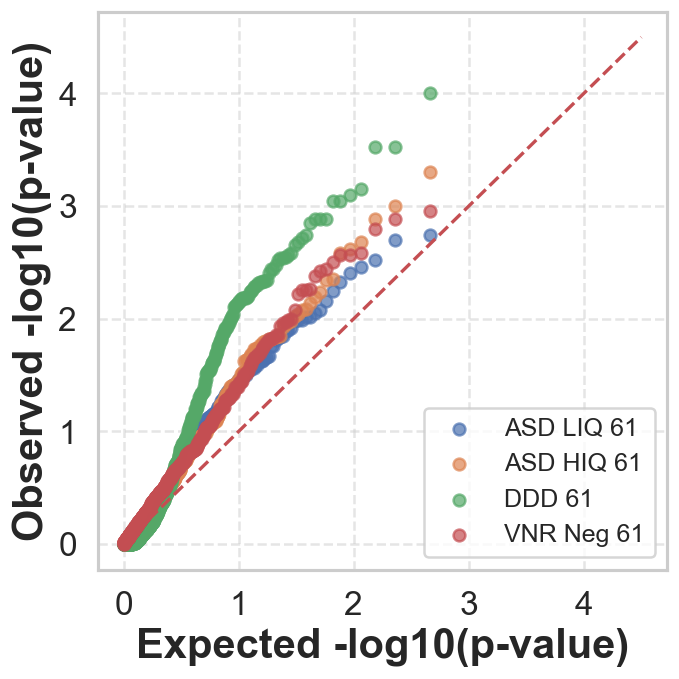

In [104]:
PlotQQ([ASD_LIQ_Bias_top61_P_randG, ASD_HIQ_Bias_top61_P_randG, DDD_hc_Bias_top61_P_randG, VNR_Neg_Bias_P_randG], 
       ["ASD LIQ 61", "ASD HIQ 61", "DDD 61", "VNR Neg 61"])

In [114]:
# Combine all supercluster level test results into wide format table
# First get unique superclusters by converting Supercluster column to Series first
superclusters = pd.concat([
    pd.Series(SuperCluster_ASD_LIQ_df['Supercluster']),
    pd.Series(SuperCluster_ASD_HIQ_df['Supercluster']), 
    pd.Series(SuperCluster_DDD_df['Supercluster']),
    pd.Series(SuperCluster_VNR_Neg_df['Supercluster']),
    pd.Series(SuperCluster_22q11_df['Supercluster'])
]).unique()

# Create empty dataframe with superclusters as index
SuperCluster_ALL_df = pd.DataFrame(index=superclusters)

# Add columns for each phenotype
for df, pheno in [(SuperCluster_ASD_LIQ_df, 'ASD_LIQ'), 
                  (SuperCluster_ASD_HIQ_df, 'ASD_HIQ'),
                  (SuperCluster_DDD_df, 'DDD'),
                  (SuperCluster_VNR_Neg_df, 'VNR_Neg'),
                  (SuperCluster_22q11_df, '22q11')]:
    
    # Create mapping dictionaries from Supercluster to values
    effect_map = dict(zip(df['Supercluster'], df['Observed_Effect']))
    pval_map = dict(zip(df['Supercluster'], df['P_value'])) 
    fdr_map = dict(zip(df['Supercluster'], df['FDR']))
    
    # Map values using the index (superclusters)
    SuperCluster_ALL_df[f'Bias_{pheno}'] = SuperCluster_ALL_df.index.map(effect_map)
    SuperCluster_ALL_df[f'P_value_{pheno}'] = SuperCluster_ALL_df.index.map(pval_map)
    SuperCluster_ALL_df[f'Adjusted_P_{pheno}'] = SuperCluster_ALL_df.index.map(fdr_map)

SuperCluster_ALL_df = SuperCluster_ALL_df.reset_index().rename(columns={'index': 'Supercluster'})

In [117]:
SuperCluster_ALL_df.to_csv("../dat/Bias_Feb27_2025/SuperCluster_ALL_df.csv", index=False)

### Other Gene Size

In [ ]:
RandGDIR_500G = "/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGenes/UniformWeights/RandGene_500/"
RandGDFs_500G = []
for i in range(10000):
    try:
        DF = pd.read_csv("{}/cont.bias.{}.csv.gz".format(RandGDIR_500G, i), index_col=0)
        RandGDFs_500G.append(DF)
    except:
        continue
print(len(RandGDFs_500G))

In [77]:
DDD_hc_Bias = pd.read_csv("../dat/Bias/HCT.DDDHC.Z2.HCT.csv", index_col=0)
DDD_hc_Bias_500_P_randG = AddPvalue(DDD_hc_Bias, RandGDFs_500G)
DDD_hc_Bias_500_P_randG.to_csv("../dat/Bias/HCT.DDDHC.Z2.HCT.addP.csv")


120
279


In [79]:
DDD_hc_Bias_500_P_randG.head(20)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation,EFFECT2,Pvalue,Z_Match,Z_Pvalue,qvalues,qvalues_ZP
136,0.425196,1,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Amygdala: 54.6%, Cerebral cortex: 36.2%, Hypot...","Human CoA: 54.6%, Human AON: 28.3%, Human HTHs...",152.0,ADCYAP CBLN CCK CHGA CHGB CRH NAMPT NUCB PYY S...,0.426776,0.0001,9.516381,8.965798e-22,0.002561,4.133233e-19
403,0.353952,2,NEUR,Splatter,NaN,GABA,"Cerebral cortex: 45.6%, Amygdala: 33.5%, Hypot...","Human AON: 25.7%, Human CoA: 18.1%, Human Pir:...",2608.0,CCK CHGB CORT NAMPT NUCB NXPH PENK SCG TAC VGF...,0.341856,0.0001,7.387138,7.501139e-14,0.002561,1.729012e-11
405,0.282077,3,NEUR,Amygdala excitatory,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 41.9%, Hypothalamus: 27.8%, A...","Human AON: 31.1%, Human HTHso: 26.6%, Human Co...",6125.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG TAC UBL VGF ...,0.288263,0.0001,6.364357,9.805460e-11,0.002561,1.130079e-08
189,0.261404,4,NEUR,Hippocampal CA1-3,NaN,VGLUT1,"Hippocampus: 73.4%, Amygdala: 24.4%, Hypothala...","Human CA1: 38.1%, Human CA1U-CA2U-CA3U: 30.7%,...",349.0,CART CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL UCN...,0.272150,0.0001,6.020475,8.695317e-10,0.002561,7.641333e-08
276,0.228518,5,NEUR,CGE interneuron,INT-VIP,GABA VGLUT3,"Hippocampus: 73.7%, Amygdala: 13.0%, Cerebral ...","Human CA3R: 12.6%, Human CA4C-DGC: 12.2%, Huma...",2080.0,CCK CHGA CHGB GRP IGF NAMPT NPY NUCB NXPH PNOC...,0.234467,0.0001,5.130749,1.442954e-07,0.002561,6.047288e-06
425,0.224721,6,NEUR,Splatter,NaN,GABA,"Thalamus: 35.4%, Hypothalamus: 29.5%, Amygdala...","Human ANC: 34.9%, Human BNST: 23.4%, Human HTH...",4253.0,AVP CCK CHGA CHGB NAMPT NPY NUCB NXPH SCG SST ...,0.224135,0.0001,4.869769,5.586452e-07,0.002561,1.839539e-05
163,0.214968,7,NEUR,Hippocampal CA1-3,NaN,VGLUT1 VGLUT2,"Amygdala: 93.5%, Hippocampus: 5.9%, Hypothalam...","Human CMN: 92.3%, Human CA1U-CA2U-CA3U: 4.9%, ...",492.0,ADCYAP CBLN CCK CHGB NAMPT NUCB PDYN SCG UBL V...,0.220915,0.0001,4.880467,5.291753e-07,0.002561,1.839539e-05
435,0.214296,8,NEUR,Midbrain-derived inhibitory,NaN,GABA,"Midbrain: 54.9%, Thalamus: 43.2%, Pons: 0.8%","Human SN-RN: 24.2%, Human CM-Pf: 13.1%, Human ...",7340.0,CBLN CHGA CHGB IGF NAMPT NPPC NUCB NXPH SCG TA...,0.216706,0.0001,4.761887,9.589551e-07,0.002561,2.947189e-05
138,0.201880,9,NEUR,Upper-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 96.4%, Basal forebrain: 1.2%,...","Human MTG: 14.3%, Human V2: 5.2%, Human A19: 4.5%",58263.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL VGF proSAAS,0.196413,0.0002,4.235782,1.138788e-05,0.003841,1.944375e-04
269,0.200441,10,NEUR,LAMP5-LHX6 and Chandelier,INT-LAMP5-LHX6,GABA,"Cerebral cortex: 43.7%, Hippocampus: 25.7%, Am...","Human MEC: 8.5%, Human CMN: 6.9%, Human CA1U-C...",3214.0,CCK CHGA CHGB IGF NAMPT NPPC NUCB NXPH PNOC SC...,0.203004,0.0001,4.512919,3.197071e-06,0.002561,7.515191e-05


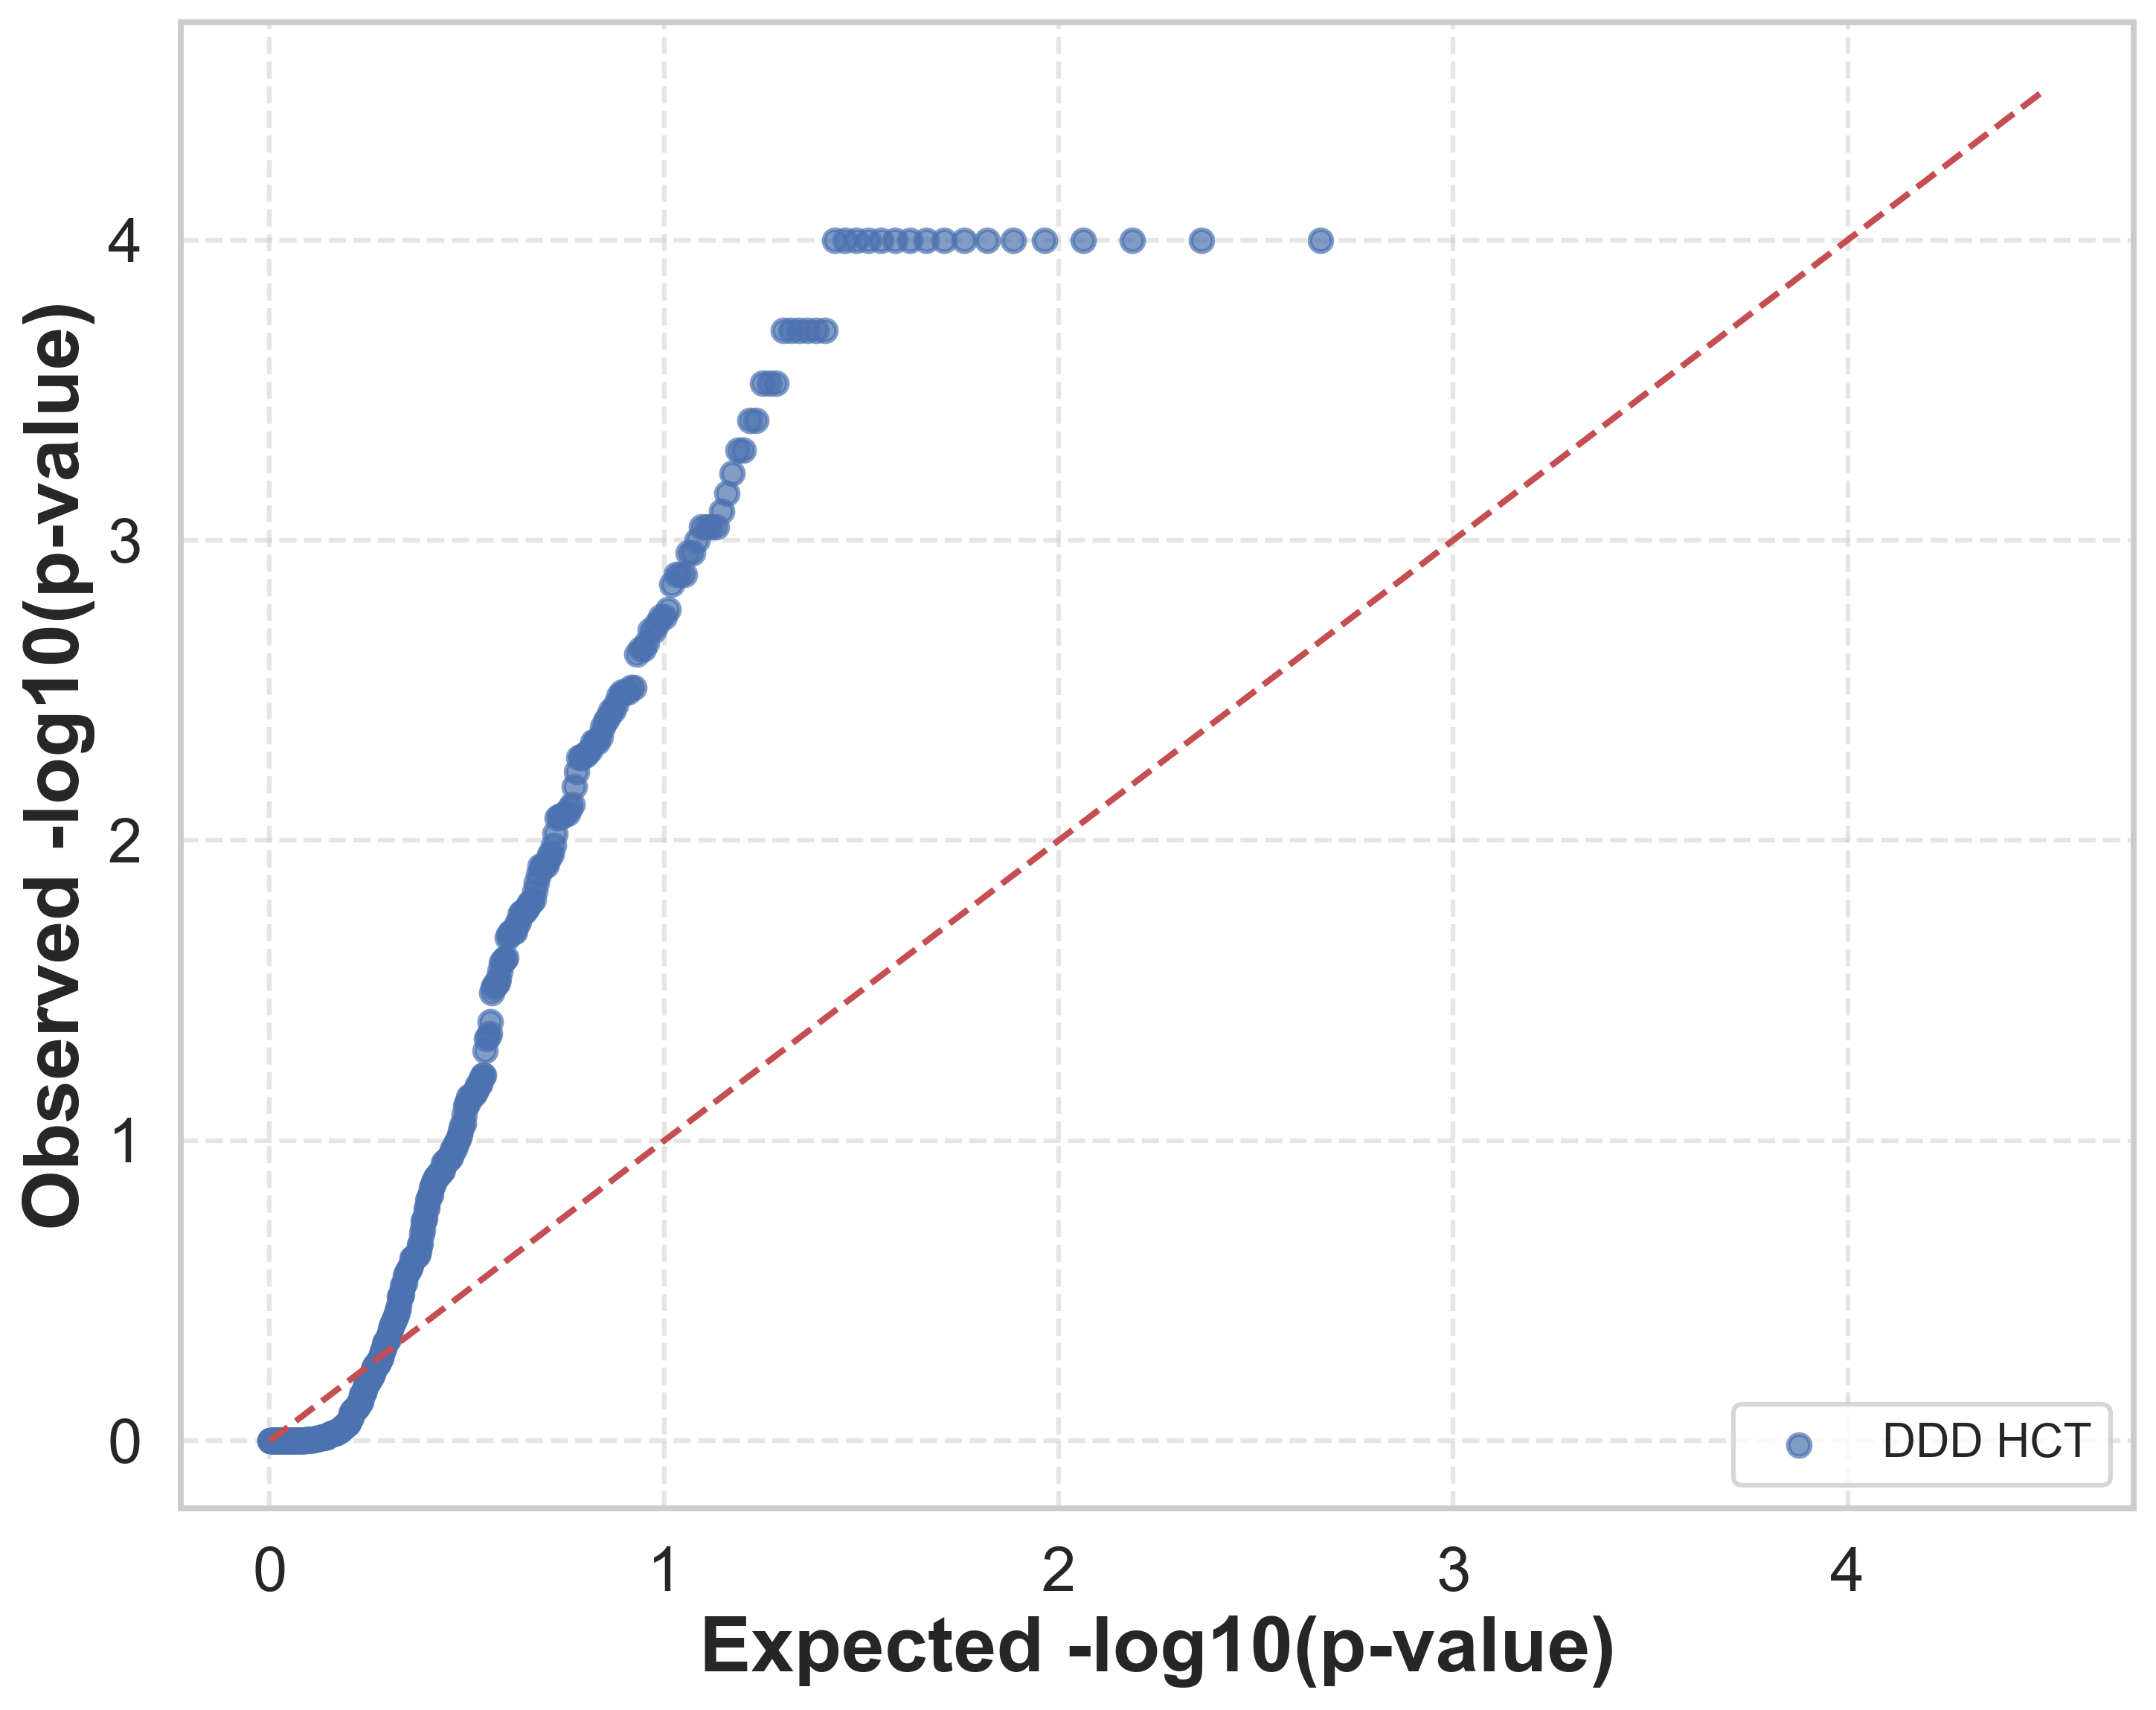

In [81]:
PlotQQ([DDD_hc_Bias_500_P_randG], 
       ["DDD HCT"])

10000


In [429]:
ASD_LIQ_163 = "/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGenes/RandGene_ASD_LIQ_top163_clip3.3_Feb20"
RandGDFs_ASD_LIQ_163 = LoadNullDF(ASD_LIQ_163)

10000


In [430]:
LIQ_Bias_top500_nopLI = pd.read_csv("../dat/Bias/HCT.ASD.LIQ.163.Z2.HCT.csv", index_col=0)
LIQ_Bias_top500_nopLI_P_randG = AddPvalue(LIQ_Bias_top500_nopLI, RandGDFs_ASD_LIQ_163)

29
174


In [433]:
LIQ_Bias_top500_nopLI_P_randG.head(20)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation,EFFECT2,Pvalue,Z_Match,Z_Pvalue,qvalues,qvalues_ZP
278,0.385587,1,NEUR,CGE interneuron,NaN,GABA VGLUT3,"Cerebral cortex: 78.0%, Amygdala: 10.4%, Hippo...","Human MEC: 5.9%, Human LEC: 4.8%, Human M1C: 4.7%",7177.0,CCK CHGA CHGB CRH IGF NAMPT NPW NUCB NXPH PNOC...,0.422834,0.000200,4.699909,0.000001,0.023048,0.000345
276,0.319969,2,NEUR,CGE interneuron,INT-VIP,GABA VGLUT3,"Hippocampus: 73.7%, Amygdala: 13.0%, Cerebral ...","Human CA3R: 12.6%, Human CA4C-DGC: 12.2%, Huma...",2080.0,CCK CHGA CHGB GRP IGF NAMPT NPY NUCB NXPH PNOC...,0.441001,0.000100,4.526822,0.000003,0.023048,0.000345
286,0.314156,3,NEUR,CGE interneuron,INT-LAMP5,GABA,"Cerebral cortex: 70.6%, Hippocampus: 13.8%, Am...","Human MEC: 5.8%, Human M1C: 5.5%, Human MTG: 4.3%",15597.0,CBLN CCK CHGA CHGB CORT CRH IGF NAMPT NPW NPY ...,0.327262,0.000700,3.749703,0.000089,0.029333,0.002915
287,0.308776,4,NEUR,CGE interneuron,INT-LAMP5,GABA,"Cerebral cortex: 53.6%, Amygdala: 17.5%, Hippo...","Human M1C: 6.2%, Human MEC: 5.8%, Human BL: 4.1%",18571.0,CBLN CCK CHGA CHGB CORT CRH IGF NAMPT NUCB NXP...,0.315890,0.000600,3.661642,0.000125,0.029333,0.003040
403,0.299575,5,NEUR,Splatter,NaN,GABA,"Cerebral cortex: 45.6%, Amygdala: 33.5%, Hypot...","Human AON: 25.7%, Human CoA: 18.1%, Human Pir:...",2608.0,CCK CHGB CORT NAMPT NUCB NXPH PENK SCG TAC VGF...,0.225748,0.011099,2.427668,0.007598,0.109477,0.044338
277,0.275238,6,NEUR,CGE interneuron,NaN,GABA VGLUT3,"Cerebral cortex: 77.4%, Amygdala: 13.3%, Hippo...","Human M1C: 6.8%, Human LEC: 5.1%, Human FI: 4.8%",1650.0,CCK CHGA CHGB CRH IGF NAMPT NUCB NXPH PNOC SCG...,0.364587,0.000500,3.860400,0.000057,0.029333,0.002372
171,0.268015,7,NEUR,Amygdala excitatory,NaN,VGLUT1 VGLUT2,"Hippocampus: 93.7%, Amygdala: 5.7%, Cerebral c...","Human CA1: 86.7%, Human Sub: 6.9%, Human CMN: ...",332.0,ADCYAP CBLN CCK CHGA CHGB NAMPT NTS NUCB PDYN ...,0.389495,0.000200,3.802521,0.000072,0.023048,0.002751
189,0.259069,8,NEUR,Hippocampal CA1-3,NaN,VGLUT1,"Hippocampus: 73.4%, Amygdala: 24.4%, Hypothala...","Human CA1: 38.1%, Human CA1U-CA2U-CA3U: 30.7%,...",349.0,CART CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL UCN...,0.381588,0.000200,3.685215,0.000114,0.023048,0.002926
405,0.245748,9,NEUR,Amygdala excitatory,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 41.9%, Hypothalamus: 27.8%, A...","Human AON: 31.1%, Human HTHso: 26.6%, Human Co...",6125.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG TAC UBL VGF ...,0.283769,0.002000,2.894717,0.001898,0.057619,0.019881
279,0.226067,10,NEUR,CGE interneuron,INT-VIP,GABA VGLUT3,"Cerebral cortex: 54.6%, Hippocampus: 26.0%, Am...","Human MEC: 5.4%, Human CMN: 5.0%, Human CA4C-D...",7444.0,CCK CHGA CHGB CRH IGF NAMPT NUCB NXPH SCG UBL ...,0.315720,0.000500,3.451296,0.000279,0.029333,0.005845


In [439]:
ASD_HIQ_188 = "/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGenes/RandGene_ASD_HIQ_top188_clip3.3_Feb20"
RandGDFs_ASD_HIQ_188 = LoadNullDF(ASD_HIQ_188)

10000


In [441]:
HIQ_Bias_top500_nopLI = pd.read_csv("../dat/Bias/HCT.ASD.HIQ.188.Z2.HCT.csv", index_col=0)
HIQ_Bias_top500_nopLI_P_randG = AddPvalue(HIQ_Bias_top500_nopLI, RandGDFs_ASD_HIQ_188)

57
189


In [442]:
HIQ_Bias_top500_nopLI_P_randG.head(20)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation,EFFECT2,Pvalue,Z_Match,Z_Pvalue,qvalues,qvalues_ZP
136,0.279568,1,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Amygdala: 54.6%, Cerebral cortex: 36.2%, Hypot...","Human CoA: 54.6%, Human AON: 28.3%, Human HTHs...",152.0,ADCYAP CBLN CCK CHGA CHGB CRH NAMPT NUCB PYY S...,0.399363,0.000100,4.461901,0.000004,0.019755,0.000633
407,0.251647,2,NEUR,Amygdala excitatory,NaN,VGLUT2 VGLUT3,"Amygdala: 72.6%, Cerebral cortex: 23.5%, Hippo...","Human CEN: 31.1%, Human CMN: 27.2%, Human A35-...",2370.0,CART CCK CHGA CHGB NAMPT NUCB NXPH SCG TAC UBL...,0.314932,0.000300,3.683458,0.000115,0.019755,0.003773
405,0.246375,3,NEUR,Amygdala excitatory,NaN,VGLUT1 VGLUT2,"Cerebral cortex: 41.9%, Hypothalamus: 27.8%, A...","Human AON: 31.1%, Human HTHso: 26.6%, Human Co...",6125.0,CBLN CCK CHGA CHGB NAMPT NUCB SCG TAC UBL VGF ...,0.285941,0.000500,3.277631,0.000523,0.020952,0.008043
220,0.243285,4,NEUR,Medium spiny neuron,MSN-D1,GABA,"Amygdala: 91.6%, Thalamus: 8.4%, Cerebral cort...","Human CEN: 87.5%, Human VA: 6.4%, Human La: 2.6%",391.0,CBLN CCK CHGA CHGB NAMPT NUCB PDYN PENK SCG SS...,0.322042,0.000500,3.666904,0.000123,0.020952,0.003773
119,0.241548,5,NEUR,Hippocampal CA1-3,NaN,VGLUT1,"Hippocampus: 97.3%, Amygdala: 1.5%, Cerebral c...","Human CA1: 27.4%, Human CA2U-CA3U: 17.2%, Huma...",6827.0,ADCYAP CHGA CHGB NAMPT NTS NUCB NXPH PYY SCG U...,0.401471,0.000100,4.458838,0.000004,0.019755,0.000633
219,0.239395,6,NEUR,Medium spiny neuron,MSN-D1,GABA,"Amygdala: 33.2%, Basal forebrain: 32.8%, Hypot...","Human SI: 31.0%, Human BNST: 23.2%, Human HTHp...",8342.0,CHGA CHGB NAMPT NUCB NXPH PDYN PENK SCG TAC UB...,0.220096,0.005499,2.709028,0.003374,0.072436,0.021603
435,0.224045,7,NEUR,Midbrain-derived inhibitory,NaN,GABA,"Midbrain: 54.9%, Thalamus: 43.2%, Pons: 0.8%","Human SN-RN: 24.2%, Human CM-Pf: 13.1%, Human ...",7340.0,CBLN CHGA CHGB IGF NAMPT NPPC NUCB NXPH SCG TA...,0.245693,0.001900,3.042178,0.001174,0.046095,0.012298
218,0.218743,8,NEUR,Medium spiny neuron,NaN,NaN,"Basal forebrain: 50.9%, Amygdala: 22.3%, Hypot...","Human SI: 38.1%, Human BNST: 19.5%, Human HTHp...",6712.0,CART CCK CHGA CHGB NAMPT NUCB SCG TAC UBL proSAAS,0.220860,0.005399,2.651894,0.004002,0.072436,0.023653
189,0.217635,9,NEUR,Hippocampal CA1-3,NaN,VGLUT1,"Hippocampus: 73.4%, Amygdala: 24.4%, Hypothala...","Human CA1: 38.1%, Human CA1U-CA2U-CA3U: 30.7%,...",349.0,CART CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL UCN...,0.339875,0.000300,3.739360,0.000092,0.019755,0.003271
382,0.213759,10,NEUR,Splatter,NaN,VGLUT2,"Amygdala: 32.1%, Hypothalamus: 30.4%, Basal fo...","Human BNST: 19.6%, Human SI: 14.2%, Human HTHp...",713.0,ADCYAP CCK CHGA CHGB IGF NAMPT NUCB NXPH SCG S...,0.309489,0.000200,3.520314,0.000216,0.019755,0.004919


In [447]:
ASD_LIQ_60_DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGenes/RandGene_ASD_LIQ_top60_clip3.3_Feb20"
RandGDFs_ASD_LIQ_60 = LoadNullDF(ASD_LIQ_60_DIR)

10000


In [448]:
LIQ_Bias_60_nopLI = pd.read_csv("../dat/Bias/HCT.ASD60.LIQ.Z2.HCT.csv", index_col=0)
LIQ_Bias_60_nopLI_P_randG = AddPvalue(LIQ_Bias_60_nopLI, RandGDFs_ASD_LIQ_60)

0
20


In [450]:
LIQ_Bias_60_nopLI_P_randG.head(20)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation,EFFECT2,Pvalue,Z_Match,Z_Pvalue,qvalues,qvalues_ZP
221,0.429214,1,NEUR,Medium spiny neuron,MSN-D2,GABA,"Basal forebrain: 78.8%, Amygdala: 9.0%, Cerebr...","Human SI: 19.8%, Human Pu: 16.4%, Human NAC: 1...",2571.0,CHGA CHGB NAMPT NUCB PENK SCG TAC UBL VGF proSAAS,0.514590,0.002400,2.971219,0.001483,0.199747,0.082863
189,0.417354,2,NEUR,Hippocampal CA1-3,NaN,VGLUT1,"Hippocampus: 73.4%, Amygdala: 24.4%, Hypothala...","Human CA1: 38.1%, Human CA1U-CA2U-CA3U: 30.7%,...",349.0,CART CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL UCN...,0.539530,0.001900,2.970957,0.001484,0.199747,0.082863
136,0.386024,3,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Amygdala: 54.6%, Cerebral cortex: 36.2%, Hypot...","Human CoA: 54.6%, Human AON: 28.3%, Human HTHs...",152.0,ADCYAP CBLN CCK CHGA CHGB CRH NAMPT NUCB PYY S...,0.504611,0.001700,2.854245,0.002157,0.199747,0.082863
190,0.379359,4,NEUR,Hippocampal CA4,NaN,VGLUT1,"Hippocampus: 100.0%, Cerebral cortex: 0.0%, Am...","Human CA3R: 68.8%, Human DGR-CA4Rpy: 17.3%, Hu...",336.0,CALCB CART CBLN CCK CHGA CHGB GNRH GRP NAMPT N...,0.493169,0.002600,2.715503,0.003309,0.199747,0.085069
276,0.356905,5,NEUR,CGE interneuron,INT-VIP,GABA VGLUT3,"Hippocampus: 73.7%, Amygdala: 13.0%, Cerebral ...","Human CA3R: 12.6%, Human CA4C-DGC: 12.2%, Huma...",2080.0,CCK CHGA CHGB GRP IGF NAMPT NPY NUCB NXPH PNOC...,0.476341,0.004000,2.801022,0.002547,0.230477,0.083871
146,0.354754,6,NEUR,Deep-layer intratelencephalic,NaN,VGLUT1 VGLUT2,"Amygdala: 65.4%, Cerebral cortex: 33.1%, Hypot...","Human Pir: 22.2%, Human CEN: 19.8%, Human BL: ...",5654.0,ADCYAP CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL V...,0.418162,0.008199,2.389061,0.008446,0.259590,0.104149
162,0.350761,7,NEUR,Amygdala excitatory,NaN,VGLUT1 VGLUT2,"Amygdala: 84.9%, Hippocampus: 8.9%, Cerebral c...","Human BL: 29.2%, Human CMN: 27.0%, Human BM: 2...",807.0,CART CBLN CCK CHGA CHGB GRP NAMPT NUCB UBL pro...,0.397102,0.012699,2.231586,0.012821,0.270560,0.104149
102,0.347637,8,NEUR,Deep-layer corticothalamic and 6b,NaN,VGLUT1,"Amygdala: 66.6%, Cerebral cortex: 28.9%, Hippo...","Human La: 18.0%, Human BL: 17.0%, Human LEC: 1...",1920.0,CBLN CCK CHGA CHGB EDN IGF NAMPT NUCB NXPH SCG...,0.448592,0.007899,2.481484,0.006542,0.259590,0.104149
154,0.346881,9,NEUR,Amygdala excitatory,NaN,VGLUT1 VGLUT2,"Amygdala: 87.5%, Cerebral cortex: 6.8%, Hippoc...","Human BL: 55.4%, Human La: 20.5%, Human BM: 8.2%",7970.0,CBLN CCK CHGA CHGB NAMPT NUCB NXPH UBL UCN VGF...,0.368649,0.016598,2.140463,0.016159,0.287328,0.106588
220,0.345845,10,NEUR,Medium spiny neuron,MSN-D1,GABA,"Amygdala: 91.6%, Thalamus: 8.4%, Cerebral cort...","Human CEN: 87.5%, Human VA: 6.4%, Human La: 2.6%",391.0,CBLN CCK CHGA CHGB NAMPT NUCB PDYN PENK SCG SS...,0.422097,0.009899,2.367962,0.008943,0.259590,0.104149


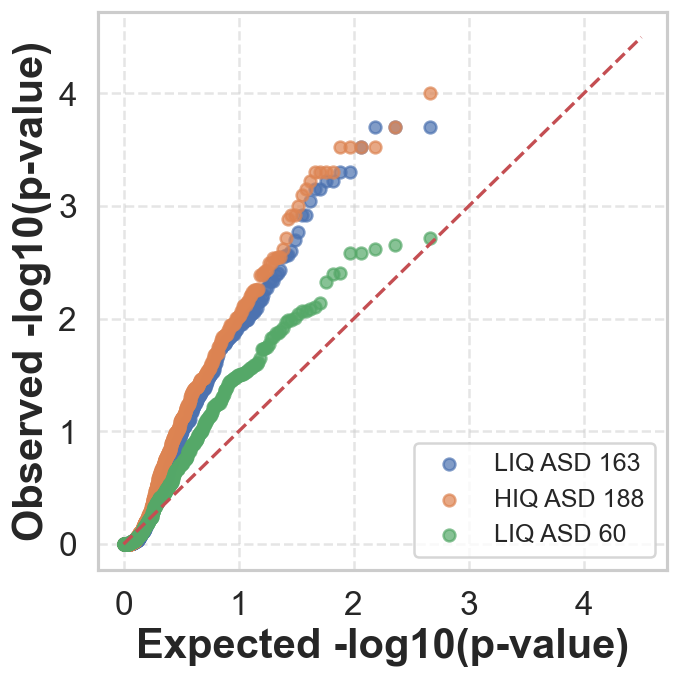

In [449]:
PlotQQ([LIQ_Bias_top500_nopLI_P_randG, HIQ_Bias_top500_nopLI_P_randG, LIQ_Bias_60_nopLI_P_randG], 
[ "LIQ ASD 163","HIQ ASD 188","LIQ ASD 60"])

In [435]:
results = []
for supercluster_to_test in ALL_CTs:
    supercluster_idx = Anno[Anno["Supercluster"]==supercluster_to_test].index
    Obs, Null, Z, P = test_supercluster_enrichment(supercluster_idx, LIQ_Bias_top500_nopLI_P_randG, RandGDFs_ASD_LIQ_163)
    results.append({
        'Supercluster': supercluster_to_test,
        'Observed_Effect': Obs,
        'Z_score': Z,
        'P_value': P
    })
SuperCluster_ASD_LIQ_163_df = pd.DataFrame(results)

Observed effect for Amygdala excitatory: 0.13204572971788714
P-value: 0.004399560043995554
Observed effect for CGE interneuron: 0.16966930231137065
P-value: 0.0034996500349965265
Observed effect for Cerebellar inhibitory: -0.026672768898386302
P-value: 0.4823517648235176
Observed effect for Deep-layer corticothalamic and 6b: 0.031221842788310247
P-value: 0.06289371062893712
Observed effect for Deep-layer intratelencephalic: 0.06819677895966911
P-value: 0.008899110088991136
Observed effect for Deep-layer near-projecting: -0.050867703416384
P-value: 0.3879612038796121
Observed effect for Eccentric medium spiny neuron: 0.07590932663448882
P-value: 0.13138686131386856
Observed effect for Hippocampal CA1-3: 0.12633574397758907
P-value: 0.003899610038996082
Observed effect for Hippocampal CA4: 0.04357030270504792
P-value: 0.06499350064993503
Observed effect for Hippocampal dentate gyrus: 0.032339190854128244
P-value: 0.48805119488051196
Observed effect for LAMP5-LHX6 and Chandelier: 0.137923

In [436]:
SuperCluster_ASD_LIQ_163_df['FDR'] = multipletests(SuperCluster_ASD_LIQ_163_df['P_value'], method='fdr_bh')[1]
SuperCluster_ASD_LIQ_163_df = SuperCluster_ASD_LIQ_163_df.sort_values(by='FDR', ascending=True)

In [437]:
SuperCluster_ASD_LIQ_163_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
0,Amygdala excitatory,0.132046,2.623868,0.004400,0.045462
1,CGE interneuron,0.169669,2.905734,0.003500,0.045462
7,Hippocampal CA1-3,0.126336,2.674737,0.003900,0.045462
14,Medium spiny neuron,0.140630,2.364425,0.010199,0.052695
10,LAMP5-LHX6 and Chandelier,0.137923,2.515983,0.008399,0.052695
4,Deep-layer intratelencephalic,0.068197,2.271058,0.008899,0.052695
15,Midbrain-derived inhibitory,0.162475,2.105639,0.023398,0.103618
8,Hippocampal CA4,0.043570,1.514923,0.064994,0.217288
3,Deep-layer corticothalamic and 6b,0.031222,1.514304,0.062894,0.217288
20,Upper-layer intratelencephalic,0.051386,1.447781,0.070093,0.217288


In [444]:
results = []
for supercluster_to_test in ALL_CTs:
    supercluster_idx = Anno[Anno["Supercluster"]==supercluster_to_test].index
    Obs, Null, Z, P = test_supercluster_enrichment(supercluster_idx, HIQ_Bias_top500_nopLI_P_randG, RandGDFs_ASD_HIQ_188)
    results.append({
        'Supercluster': supercluster_to_test,
        'Observed_Effect': Obs,
        'Z_score': Z,
        'P_value': P
    })
SuperCluster_ASD_HIQ_188_df = pd.DataFrame(results)

Observed effect for Amygdala excitatory: 0.1050491418026293
P-value: 0.004499550044995471
Observed effect for CGE interneuron: -0.028718403149886152
P-value: 0.5495450454954505
Observed effect for Cerebellar inhibitory: -0.03675125935844607
P-value: 0.5608439156084392
Observed effect for Deep-layer corticothalamic and 6b: 0.04988378352673751
P-value: 0.02399760023997599
Observed effect for Deep-layer intratelencephalic: 0.0887963580118123
P-value: 0.0018998100189980827
Observed effect for Deep-layer near-projecting: -0.009523965585202205
P-value: 0.19588041195880412
Observed effect for Eccentric medium spiny neuron: 0.11747523758192491
P-value: 0.027597240275972434
Observed effect for Hippocampal CA1-3: 0.10257636673356155
P-value: 0.004599540045995387
Observed effect for Hippocampal CA4: 0.052279904175846666
P-value: 0.0333966603339666
Observed effect for Hippocampal dentate gyrus: 0.011651799195014944
P-value: 0.5889411058894111
Observed effect for LAMP5-LHX6 and Chandelier: -0.01359

In [445]:
SuperCluster_ASD_HIQ_188_df['FDR'] = multipletests(SuperCluster_ASD_HIQ_188_df['P_value'], method='fdr_bh')[1]
SuperCluster_ASD_HIQ_188_df = SuperCluster_ASD_HIQ_188_df.sort_values(by='FDR', ascending=True)

In [446]:
SuperCluster_ASD_HIQ_188_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
0,Amygdala excitatory,0.105049,2.537551,0.004500,0.047529
4,Deep-layer intratelencephalic,0.088796,2.852686,0.001900,0.047529
7,Hippocampal CA1-3,0.102576,2.663783,0.004600,0.047529
14,Medium spiny neuron,0.123240,2.470803,0.007599,0.058894
13,Mammillary body,0.080001,2.108865,0.015998,0.099190
3,Deep-layer corticothalamic and 6b,0.049884,1.970233,0.023998,0.122216
6,Eccentric medium spiny neuron,0.117475,1.947618,0.027597,0.122216
8,Hippocampal CA4,0.052280,1.867994,0.033397,0.129412
15,Midbrain-derived inhibitory,0.123471,1.848869,0.037796,0.130187
16,Miscellaneous,0.007478,0.999546,0.157284,0.487581


In [451]:
results = []
for supercluster_to_test in ALL_CTs:
    supercluster_idx = Anno[Anno["Supercluster"]==supercluster_to_test].index
    Obs, Null, Z, P = test_supercluster_enrichment(supercluster_idx, LIQ_Bias_60_nopLI_P_randG, RandGDFs_ASD_LIQ_60)
    results.append({
        'Supercluster': supercluster_to_test,
        'Observed_Effect': Obs,
        'Z_score': Z,
        'P_value': P
    })
SuperCluster_ASD_LIQ_60_df = pd.DataFrame(results)

Observed effect for Amygdala excitatory: 0.2183548122391445
P-value: 0.011798820117988162
Observed effect for CGE interneuron: 0.10699800904872933
P-value: 0.13138686131386856
Observed effect for Cerebellar inhibitory: -0.03671649192008493
P-value: 0.5234476552344766
Observed effect for Deep-layer corticothalamic and 6b: 0.1398082616713722
P-value: 0.053594640535946425
Observed effect for Deep-layer intratelencephalic: 0.1815765451145765
P-value: 0.014798520147985217
Observed effect for Deep-layer near-projecting: 0.021929253888000204
P-value: 0.2704729527047295
Observed effect for Eccentric medium spiny neuron: 0.14392025395191385
P-value: 0.12328767123287676
Observed effect for Hippocampal CA1-3: 0.20441433568785372
P-value: 0.016498350164983466
Observed effect for Hippocampal CA4: 0.15059123240341848
P-value: 0.05569443055694434
Observed effect for Hippocampal dentate gyrus: 0.0933069032800152
P-value: 0.3077692230776923
Observed effect for LAMP5-LHX6 and Chandelier: 0.0944854593644

In [470]:
SuperCluster_ASD_LIQ_60_df['FDR'] = multipletests(SuperCluster_ASD_LIQ_60_df['P_value'], method='fdr_bh')[1]
SuperCluster_ASD_LIQ_60_df = SuperCluster_ASD_LIQ_60_df.sort_values(by='FDR', ascending=True)
SuperCluster_ASD_LIQ_60_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
0,Amygdala excitatory,0.218355,2.179996,0.011799,0.142586
14,Medium spiny neuron,0.252413,2.153194,0.018398,0.142586
7,Hippocampal CA1-3,0.204414,2.109342,0.016498,0.142586
4,Deep-layer intratelencephalic,0.181577,2.140837,0.014799,0.142586
8,Hippocampal CA4,0.150591,1.602657,0.055694,0.249746
15,Midbrain-derived inhibitory,0.223721,1.622107,0.056394,0.249746
3,Deep-layer corticothalamic and 6b,0.139808,1.615279,0.053595,0.249746
6,Eccentric medium spiny neuron,0.143920,1.154254,0.123288,0.436775
10,LAMP5-LHX6 and Chandelier,0.094485,1.066262,0.142986,0.436775
20,Upper-layer intratelencephalic,0.079456,0.997637,0.154985,0.436775


In [471]:
SuperCluster_ASD_LIQ_60_df

,Supercluster,Observed_Effect,Z_score,P_value,FDR
0,Amygdala excitatory,0.218355,2.179996,0.011799,0.142586
14,Medium spiny neuron,0.252413,2.153194,0.018398,0.142586
7,Hippocampal CA1-3,0.204414,2.109342,0.016498,0.142586
4,Deep-layer intratelencephalic,0.181577,2.140837,0.014799,0.142586
8,Hippocampal CA4,0.150591,1.602657,0.055694,0.249746
15,Midbrain-derived inhibitory,0.223721,1.622107,0.056394,0.249746
3,Deep-layer corticothalamic and 6b,0.139808,1.615279,0.053595,0.249746
6,Eccentric medium spiny neuron,0.143920,1.154254,0.123288,0.436775
10,LAMP5-LHX6 and Chandelier,0.094485,1.066262,0.142986,0.436775
20,Upper-layer intratelencephalic,0.079456,0.997637,0.154985,0.436775
